In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('..\\data\\data_preprocessing.csv')

In [3]:
df.head()

,gender,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,ratio_pression
0,male,39,level 4,No,0.0,No,No,No,No,195.0,106.0,70.0,26.97,80.0,77.0,0,1.514286
1,female,46,level 2,No,0.0,No,No,No,No,250.0,121.0,81.0,28.73,95.0,76.0,0,1.493827
2,male,48,level 1,Yes,20.0,No,No,No,No,245.0,127.5,80.0,25.34,75.0,70.0,0,1.593750
3,female,61,level 3,Yes,30.0,No,No,Yes,No,225.0,150.0,95.0,28.58,65.0,103.0,1,1.578947
4,female,46,level 3,Yes,23.0,No,No,No,No,285.0,130.0,84.0,23.10,85.0,85.0,0,1.547619


In [4]:
df.shape

(4082, 17)

In [5]:
df.columns

Index(['gender', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD', 'ratio_pression'],
      dtype='object')

In [6]:
# Encodons les variables ordinales

df['education'] = df['education'].replace({'level 1' : 1, 'level 2' : 2, 'level 3' : 3, 'level 4' : 4})
# df['gender'] = df['gender'].replace({'male' : 1, 'female' : 0})
# df['BPMeds'] = df['BPMeds'].replace({'Yes' : 1, 'No' : 0})
# df['currentSmoker'] = df['currentSmoker'].replace({'Yes' : 1, 'No' : 0})
# df['prevalentStroke'] = df['prevalentStroke'].replace({'Yes' : 1, 'No' : 0})
# df['prevalentHyp'] = df['prevalentHyp'].replace({'Yes' : 1, 'No' : 0})
# df['diabetes'] = df['diabetes'].replace({'Yes' : 1, 'No' : 0})

In [7]:
df.isnull().sum()

gender             0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
ratio_pression     0
dtype: int64

# Divisions du jeu de donnee

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop('TenYearCHD', axis = 1)
y = df['TenYearCHD']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, random_state = 42, test_size = 0.2)

# Encodage des donnees categorielles

In [9]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA

pca = PCA(n_components = 0.95)

In [70]:
ohe = OneHotEncoder(sparse_output = False, handle_unknown = 'ignore', drop = 'first')

colonnes_categorielles = X.select_dtypes(include = 'object').columns
colonnes_numeriques =  X.select_dtypes(include = 'number').columns

X_train_encoded = ohe.fit_transform(X_train[colonnes_categorielles])
feature_names = ohe.get_feature_names_out()
X_train_encoded = pd.DataFrame(X_train_encoded, columns = feature_names, index = X_train.index)
X_train_final = X_train.select_dtypes(include = 'number')
X_train_final = pd.concat([X_train_final.reset_index(drop = True), X_train_encoded.reset_index(drop = True)], axis = 1)
X_train_final.index = X_train.index

X_test_encoded = ohe.transform(X_test[colonnes_categorielles])
feature_names = ohe.get_feature_names_out()
X_test_encoded = pd.DataFrame(X_test_encoded, columns = feature_names, index = X_test.index)
X_test_final = X_test.select_dtypes(include = 'number')
X_test_final = pd.concat([X_test_final, X_test_encoded], axis = 1,  ignore_index = False)


scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train_final)
feature_names = scaler.get_feature_names_out()
X_train_final = pd.DataFrame(X_train_final, columns = feature_names)

X_test_final = scaler.transform(X_test_final)
feature_names = scaler.get_feature_names_out()
X_test_final = pd.DataFrame(X_test_final, columns = feature_names)
X_test_final.columns


#On doit appliquer SMOTE apres l'encodage et la normalisation
ratio_desire = 0.4 / 0.6  
smote = SMOTE(random_state=42, sampling_strategy= ratio_desire)#'auto')#, categorical_features = [i for i in range(len(X_train.columns))])
X_train_smote, y_train_smote = smote.fit_resample(X_train_final, y_train)
y_train_smote.value_counts()


X_train_pca = pca.fit_transform(X_train_smote)
print(pca.get_feature_names_out())
X_test_pca = pca.transform(X_test_final)
pca.get_feature_names_out()

['pca0' 'pca1' 'pca2' 'pca3' 'pca4' 'pca5' 'pca6' 'pca7' 'pca8' 'pca9'
 'pca10' 'pca11' 'pca12']


array(['pca0', 'pca1', 'pca2', 'pca3', 'pca4', 'pca5', 'pca6', 'pca7',
       'pca8', 'pca9', 'pca10', 'pca11', 'pca12'], dtype=object)

<Axes: >

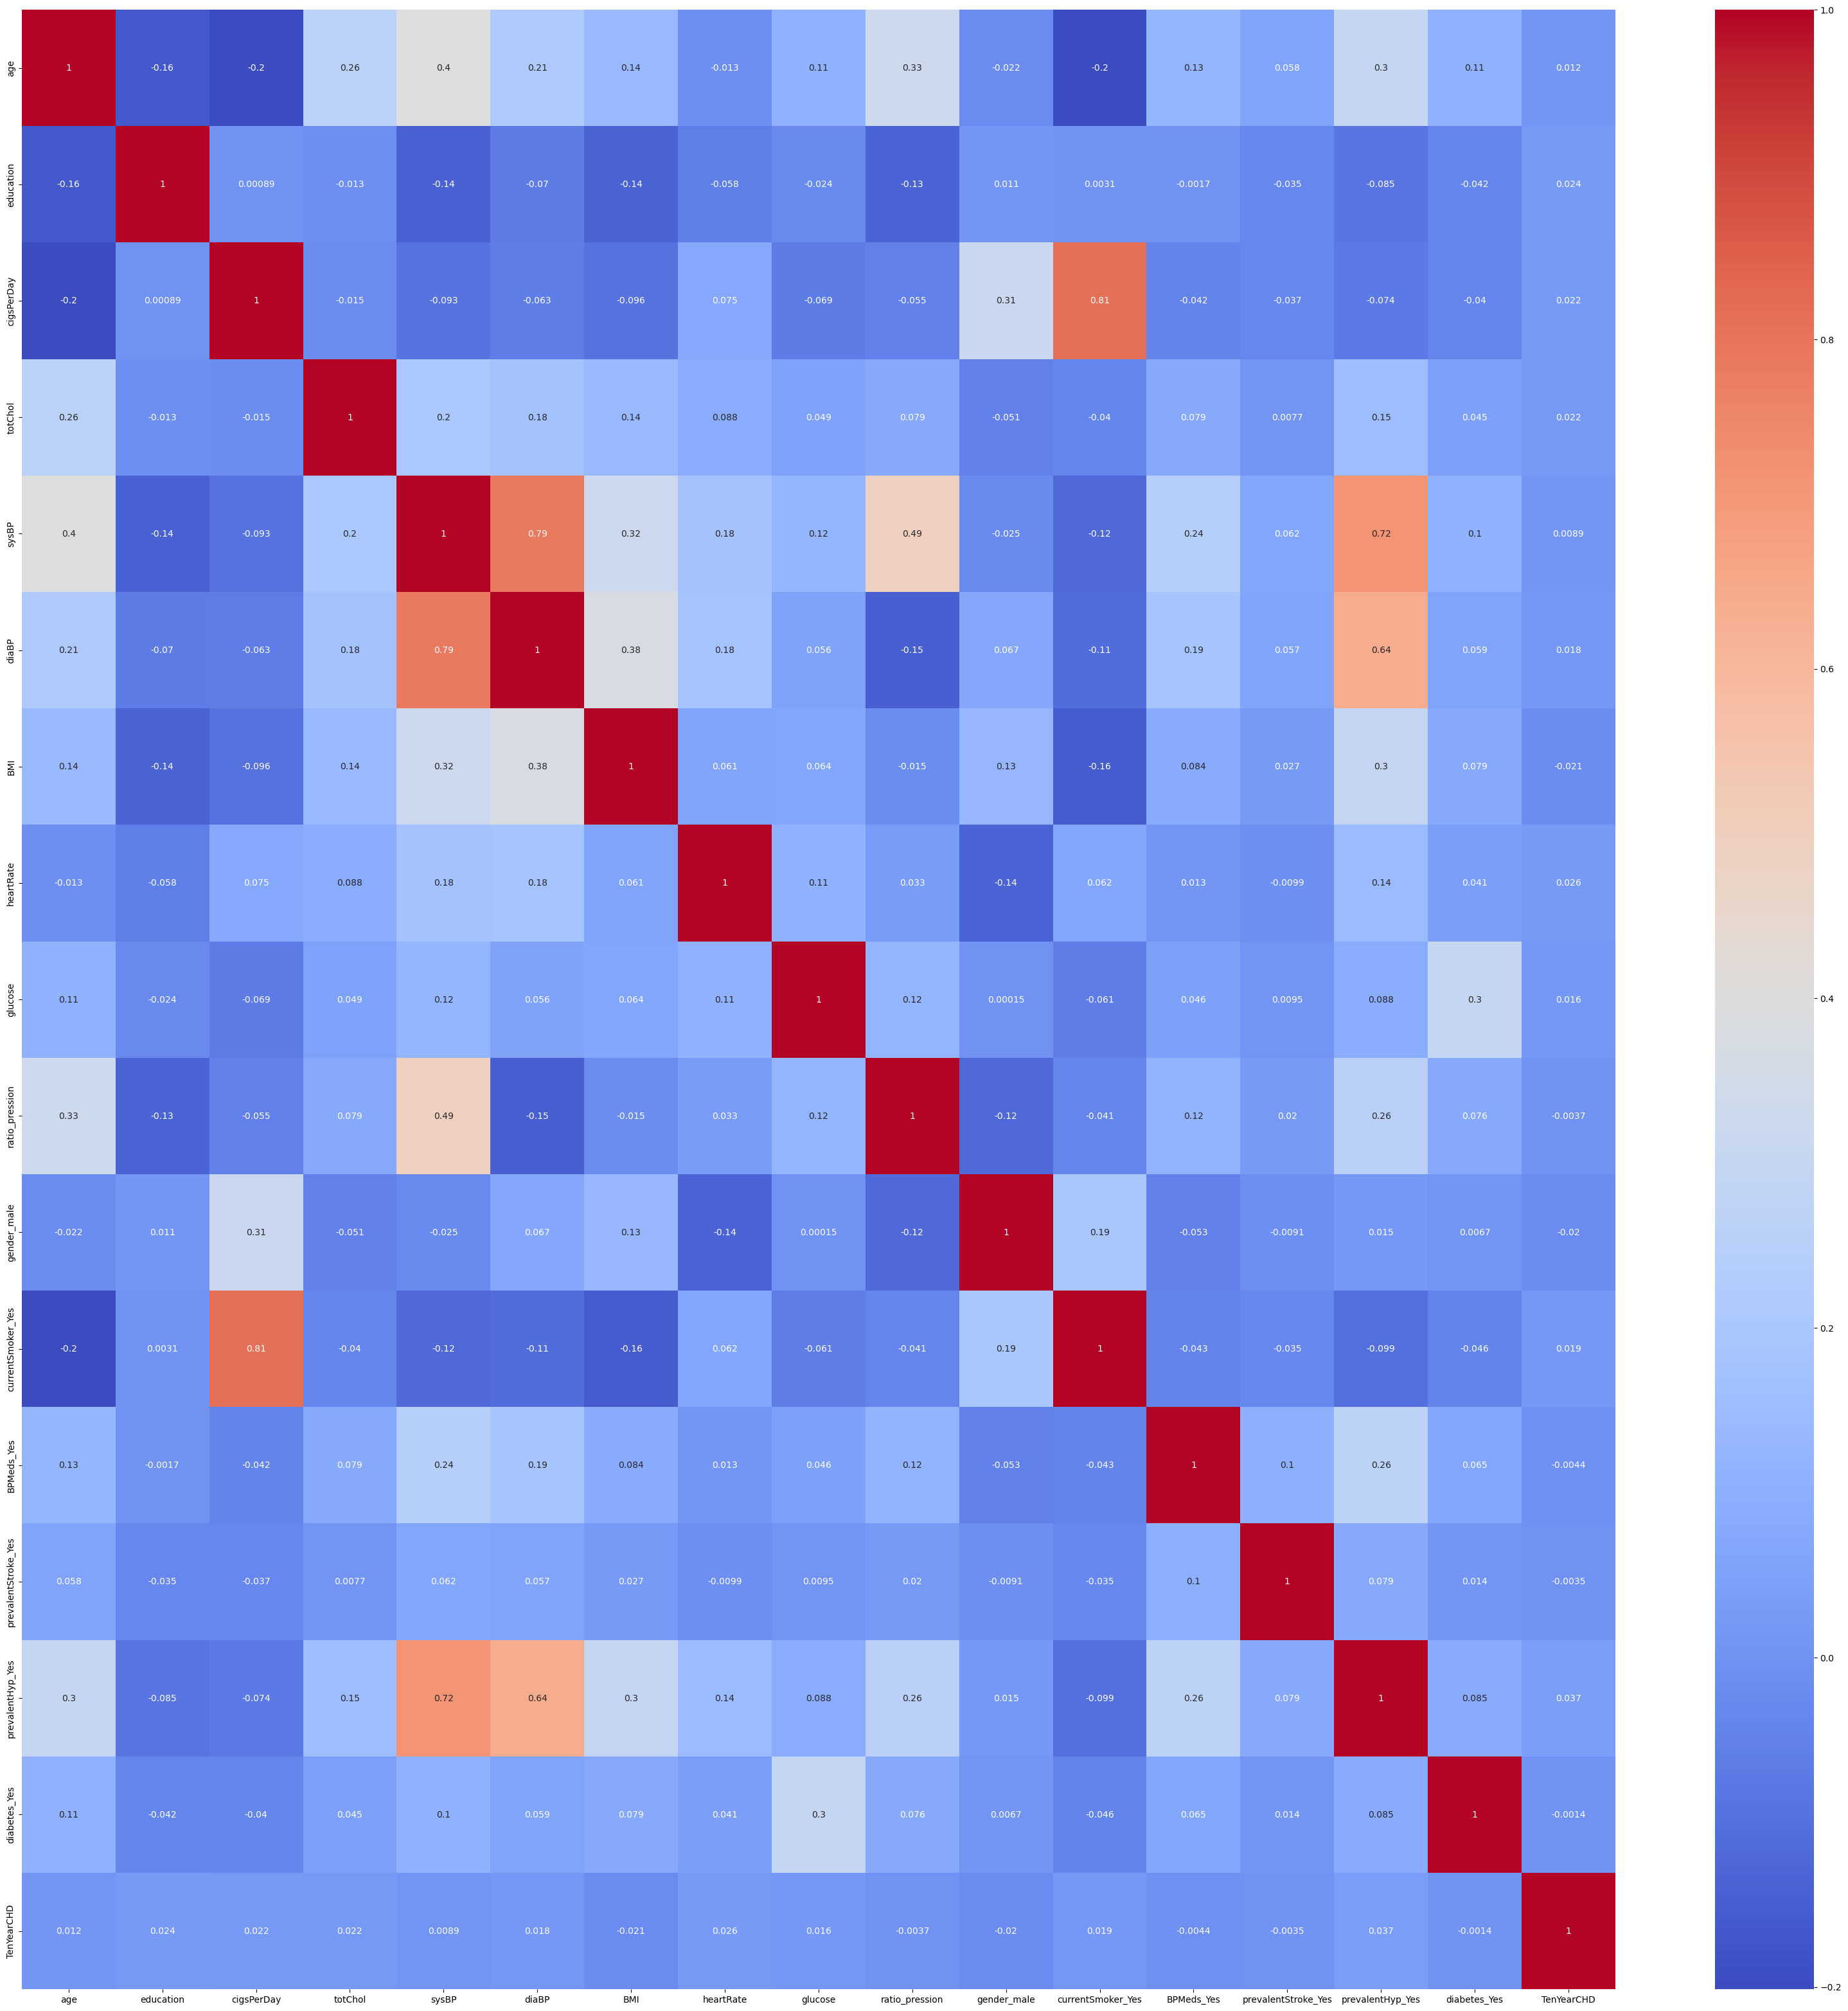

In [44]:
plt.figure(figsize = (40, 40))
sns.heatmap((pd.concat([X_train_final, y_train], axis = 1)).corr(), annot = True, cmap = 'coolwarm')
# On observe une multicolinearite sur les variables explicatives

# Entrainement et evaluation du modele de regression logistique

accuracy-score : 0.7454100367197063
precision-score : 0.5040650406504065
recall-score : 0.2966507177033493
f1-score : 0.37349397590361444
confusion-matrix : [[547  61]
 [147  62]]
classification report :               precision    recall  f1-score   support

           0       0.79      0.90      0.84       608
           1       0.50      0.30      0.37       209

    accuracy                           0.75       817
   macro avg       0.65      0.60      0.61       817
weighted avg       0.72      0.75      0.72       817

confusion _matrix: [[547 147]
 [ 61  62]]


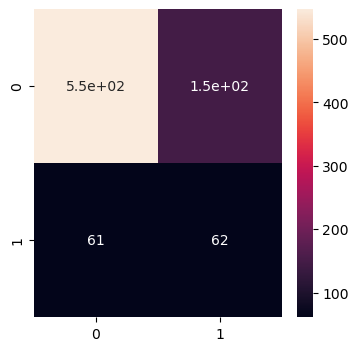

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA

models = {'logistic_regression' : LogisticRegression()}

lg = models['logistic_regression']

def trainer(X_train, X_test, y_train, y_test, model) :
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test) 
    lg = model
    print(f'accuracy-score : {accuracy_score(y_test, y_pred)}')
    print(f'precision-score : {precision_score(y_pred, y_test)}')
    print(f'recall-score : {recall_score(y_pred, y_test)}')
    print(f'f1-score : {f1_score(y_pred, y_test)}')
    print(f'confusion-matrix : {confusion_matrix(y_pred, y_test)}')
    print(f'classification report : {classification_report(y_pred, y_test)}')
    cf_matrix = confusion_matrix(y_test,y_pred)
    plt.figure(figsize = (4, 4))
    sns.heatmap(cf_matrix, annot = True)
    print(f"confusion _matrix: {cf_matrix}")

for name in models.keys() :
    trainer(X_train_smote, X_test_final, y_train_smote, y_test, models[name]) 

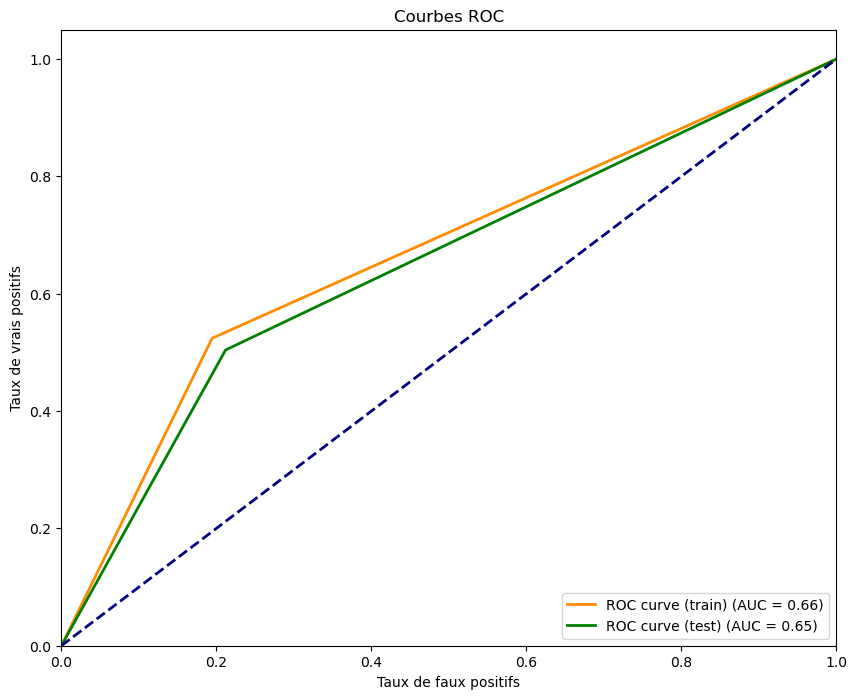

In [72]:
from sklearn.metrics import roc_curve, auc
# Obtenir les prédictions du modèle sur l'ensemble d'entraînement et de test
models['logistic_regression'].fit(X_train_smote, y_train_smote)

y_train_pred = models['logistic_regression'].predict(X_train_smote)
y_test_pred = models['logistic_regression'].predict(X_test_final)

# Calculer les courbes ROC et les aires sous la courbe (AUC)
fpr_train, tpr_train, thresholds_train = roc_curve(y_train_smote, y_train_pred)
roc_auc_train = auc(fpr_train, tpr_train)

fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_pred)
roc_auc_test = auc(fpr_test, tpr_test)

# Tracer les courbes ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2, label='ROC curve (train) (AUC = %0.2f)' % roc_auc_train)
plt.plot(fpr_test, tpr_test, color='green', lw=2, label='ROC curve (test) (AUC = %0.2f)' % roc_auc_test)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC')
plt.legend(loc="lower right")
plt.show()

# Validation croisee

In [73]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

#  Optimisation des hyperparamètres
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

cv_strategy = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
cv_score = cross_val_score(models['logistic_regression'], X_train_smote, y_train_smote, cv = cv_strategy, scoring= 'recall')

result = {}
result['scrore'] = cv_score
result['std'] = cv_score.std()
result['min'] = cv_score.min()
result['max'] = cv_score.max()
result['mean'] = cv_score.mean()

pd.DataFrame(result)

,scrore,std,min,max,mean
0,0.518919,0.020485,0.479675,0.536585,0.515973
1,0.510811,0.020485,0.479675,0.536585,0.515973
2,0.536585,0.020485,0.479675,0.536585,0.515973
3,0.479675,0.020485,0.479675,0.536585,0.515973
4,0.533875,0.020485,0.479675,0.536585,0.515973


# Optimisation Des Hyperparametres

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'penalty' : ['l1', 'l2', 'elasticnet', None],
    'C' : [0.001, 0.01, 0.1, 1, 10, 100],
    'solver' : ['saga', 'lbfgs', 'liblinear'],#['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
    'max_iter' : [100, 500, 1000],
    'class_weight' : [None, 'balanced', {0: 1, 1: 2.33}, {0: 1, 1:3}],
    'l1_ratio' : [0, 0.15, 0.5, 0.85, 0.9, 1]
    # 'fit_intercept' : [True, False],
    # 'tol' : [1e-4, 1e-3, "1e-2]
}
def optimize_model(model, param_grid, X, y, cv=3):
    """Optimisation avec GridSearchCV"""
    grid_search = GridSearchCV(
        model, param_grid, cv=cv_strategy, 
        # scoring='f1', n_jobs=-1, verbose=0, return_train_score=True
    scoring = {
        'recall' : 'recall',
        'f1' : 'f1', 
        'roc_auc' : 'roc_auc',
        'precision' : 'precision',
        'balanced_accuracy'  : 'balanced_accuracy'
    },
    refit = 'recall',
    n_jobs = -1,
    verbose = 1,
    return_train_score = True
    )
    grid_search.fit(X, y)
    
    print(f"Best score: {grid_search.best_score_:.3f}")
    print(f"Best params: {grid_search.best_params_}")
    
    return grid_search



grid_search = optimize_model(models['logistic_regression'], param_grid, X_train_smote, y_train_smote, cv = cv_strategy)

Fitting 5 folds for each of 5184 candidates, totalling 25920 fits


In [ ]:
model = LogisticRegression(**grid_search.best_params_, random_state = 42)

trainer(X_train_smote, X_test_final, y_train_smote, y_test, model)

In [89]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, loguniform, randint


param_dist = {
    'C' : loguniform(1e-4, 1e4),
    'penalty' : ['l1', 'l2', 'elasticnet', None],
    'solver' : ['liblinear', 'newton-cg'],#, 'lbfgs', 'sag', 'saga'],
    'class_weight' : [None, 'balanced', {0: 1, 1: 2.33}, {0: 1, 1:3}, {0 : 1, 1: 4}, {0: 1, 1: 5}],
    'l1_ratio' : uniform(0, 1),
    'fit_intercept' : [True, False],
    'tol' : loguniform(1e-5, 1e-2),
    'max_iter' : [100, 200, 500, 1000, 2000]
}

random_search = RandomizedSearchCV(
    models['logistic_regression'],
    param_dist,
    n_iter = 100,
    cv = cv_strategy,
    scoring = {
        'recall' : 'recall',
        'f1' : 'f1', 
        'roc_auc' : 'roc_auc',
        'precision' : 'precision',
        'balanced_accuracy'  : 'balanced_accuracy'
    },
    refit = 'recall',
    n_jobs = -1,
    random_state = 42,
    verbose = 1,
    return_train_score = True
)

random_search.fit(X_train_smote, y_train_smote)

print(f"Best score: {random_search.best_score_:.3f}")
print(f"Best params: {random_search.best_params_}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits


BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

In [ ]:
#Prediction avec le meilleur modele
model = LogisticRegression(**random_search.best_params_, random_state = 42)


for name in models.keys() :
    trainer(X_train_smote, X_test_final, y_train_smote, y_test, model) 

In [ ]:
lg.coef_[0]

In [ ]:
# Extraire les coefficients

coefficients = pd.DataFrame(
    {
        'Feature' : X_train_smote.columns,
        'Coefficient' : lg.coef_[0]
    }
).sort_values(by = 'Coefficient', ascending = False)
coefficients['Importance'] = np.abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values('Importance', ascending = False)
coefficients

In [ ]:
plt.figure(figsize = (10, 10))

colors = ['green' if c > 0 else 'red' for c in coefficients['Coefficient']]

plt.barh(coefficients['Feature'], coefficients['Coefficient'], color = colors)
plt.axvline(x = 0, color = 'black', linewidth = 0.8)
plt.xlabel("Valeur du coefficient")
# plt.tight_layout()
# plt.show()

# Calcul de l'Odds Ratio

In [ ]:
coefficients['Odds_Ratio'] = np.exp(coefficients['Coefficient'])
coefficients[['Feature', 'Coefficient', 'Odds_Ratio']]